LINK VIDEO GOOGLE DRIVE:

No 1 : https://drive.google.com/file/d/1HiUymQaMJ9d8gHEQVrqdyLFP7JDcwYUi/view?usp=drive_link

No 2 : https://drive.google.com/file/d/1TJbTbz0n7gKaoeZExK6dMZHTjS4bw4BB/view?usp=drive_link

No 3 : https://drive.google.com/file/d/1e1W1YgUNfTjv__x0Sm34cEI55jpjqQ5L/view?usp=drive_link

No 4 : https://drive.google.com/file/d/1bm9LYh02JL5gowSf2jYVceGUJyxo1wpS/view?usp=drive_link

## no 1 a

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load Dataset

df = pd.read_parquet('1A.parquet')
df.head()

,farm_id,region,crop_type,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,irrigation_type,...,sowing_date,harvest_date,total_days,sensor_id,timestamp,latitude,longitude,NDVI_index,crop_disease_status,yield
0,FARM0001,North India,Wheat,35.95,5.99,17.79,75.62,77.03,7.27,None,...,2024-01-08,2024-05-09,122,SENS0001,2024-03-19,14.970941,82.997689,0.63,Mild,44080.7
1,FARM0002,South USA,Soybean,19.74,7.24,30.18,89.91,61.13,5.67,Sprinkler,...,2024-02-04,2024-05-26,112,SENS0002,2024-04-21,16.613022,70.869009,0.58,None,53899.8
2,FARM0003,South USA,Wheat,29.32,7.16,27.37,265.43,68.87,8.23,Drip,...,2024-02-03,2024-06-26,144,SENS0003,2024-02-28,19.503156,79.068206,0.80,Mild,29311.6
3,FARM0004,Central USA,Maize,17.33,6.03,33.73,212.01,70.46,5.03,Sprinkler,...,2024-02-21,2024-07-04,134,SENS0004,2024-05-14,31.071298,85.519998,0.44,None,42278.0
4,FARM0005,Central USA,Cotton,19.37,5.92,33.86,269.09,55.73,7.93,None,...,2024-02-05,2024-05-20,105,SENS0005,2024-04-13,16.56854,81.691720,0.84,Severe,49799.6


In [ ]:
# 2. Basic EDA
print("Info Dataset")
print(df.info())
print("\nMissing Values")
print(df.isna().sum())

--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   farm_id              500 non-null    object 
 1   region               500 non-null    object 
 2   crop_type            500 non-null    object 
 3   soil_moisture_%      500 non-null    float64
 4   soil_pH              500 non-null    object 
 5   temperature_C        500 non-null    float64
 6   rainfall_mm          500 non-null    float64
 7   humidity_%           500 non-null    float64
 8   sunlight_hours       499 non-null    float64
 9   irrigation_type      350 non-null    object 
 10  fertilizer_type      500 non-null    object 
 11  pesticide_usage_ml   500 non-null    float64
 12  sowing_date          500 non-null    object 
 13  harvest_date         500 non-null    object 
 14  total_days           500 non-null    int64  
 15  sensor_id          

In [ ]:
# Identifikasi masalah:
# - farm_id, sensor_id, timestamp, sowing_date, harvest_date adalah ID/Metadata (Drop)
# - Kolom kategori perlu di-encoding (region, crop_type, irrigation_type, fertilizer_type, crop_disease_status)
# - irrigation_type dan crop_disease_status mungkin memiliki nilai kosong (dianggap 'Unknown')

# 3. Pre-processing
# Drop kolom yang tidak relevan untuk prediksi numerik
drop_cols = ['farm_id', 'sensor_id', 'timestamp', 'sowing_date', 'harvest_date', 'latitude', 'longitude']
df = df.drop(columns=drop_cols)

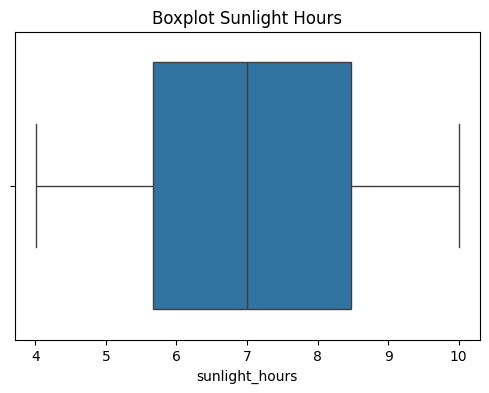

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(x=df['sunlight_hours'])
plt.title('Boxplot Sunlight Hours')
plt.show()

In [ ]:
# Handling Missing Values (Simple imputation)
df['irrigation_type'] = df['irrigation_type'].fillna('Unknown')
df['crop_disease_status'] = df['crop_disease_status'].fillna('Healthy')
df['sunlight_hours'] = df['sunlight_hours'].fillna(df['sunlight_hours'].mean())

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   region               500 non-null    object 
 1   crop_type            500 non-null    object 
 2   soil_moisture_%      500 non-null    float64
 3   soil_pH              500 non-null    object 
 4   temperature_C        500 non-null    float64
 5   rainfall_mm          500 non-null    float64
 6   humidity_%           500 non-null    float64
 7   sunlight_hours       500 non-null    float64
 8   irrigation_type      500 non-null    object 
 9   fertilizer_type      500 non-null    object 
 10  pesticide_usage_ml   500 non-null    float64
 11  total_days           500 non-null    int64  
 12  NDVI_index           500 non-null    float64
 13  crop_disease_status  500 non-null    object 
 14  yield                500 non-null    float64
dtypes: float64(8), int64(1), object(6)
memor

In [ ]:
# Pisahkan Fitur dan Target
X = df.drop('yield', axis=1)
y = df['yield']

In [ ]:
# Identifikasi tipe kolom
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()

In [ ]:
# 4. Data Splitting (70:10:20)
# Split pertama: 80% (Train+Val) dan 20% Test
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
# Split kedua: Dari 80%, ambil 12.5% untuk Val (karena 0.125 * 0.8 = 0.10 dari total)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.125, random_state=42)

In [ ]:
# 5. Transformation Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

X_train = preprocessor.fit_transform(X_train)
X_val = preprocessor.transform(X_val)
X_test = preprocessor.transform(X_test)

In [ ]:
# Scaling Target
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_val = scaler_y.transform(y_val.values.reshape(-1, 1))
y_test = scaler_y.transform(y_test.values.reshape(-1, 1))

print(f"\nShape Final: Train {X_train.shape}, Val {X_val.shape}, Test {X_test.shape}")


Shape Final: Train (350, 195), Val (50, 195), Test (100, 195)


## No 1 b

In [ ]:
input_dim = X_train.shape[1]

# Arsitektur Baseline
baseline_model = tf.keras.Sequential([
    tf.keras.layers.Dense(input_dim * 2, activation='relu', input_shape=(input_dim,)),
    tf.keras.layers.Dense(input_dim * 2, activation='relu'),
    tf.keras.layers.Dense(1, activation='linear')
])

baseline_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("\n--- Summary Baseline Model ---")
baseline_model.summary()


--- Summary Baseline Model ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_35 (Dense)                │ (None, 390)            │        76,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 390)            │       152,490 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1)              │           391 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 229,321 (895.79 KB)

 Trainable params: 229,321 (895.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 1.1182 - mae: 0.9033 - val_loss: 1.0051 - val_mae: 0.8765
Epoch 2/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.8077 - mae: 0.7697 - val_loss: 0.9732 - val_mae: 0.8589
Epoch 3/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.6815 - mae: 0.7001 - val_loss: 1.1580 - val_mae: 0.9126
Epoch 4/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.5398 - mae: 0.6153 - val_loss: 1.0235 - val_mae: 0.8820
Epoch 5/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3626 - mae: 0.4873 - val_loss: 1.0668 - val_mae: 0.8799
Epoch 6/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2597 - mae: 0.3999 - val_loss: 1.1191 - val_mae: 0.8988
Epoch 7/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1354 - mae: 0.2858 - val_loss: 1.2102 - val_mae: 0.9357
Epoch 8/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0729 - mae: 0.2019 - val_loss: 1.2432 - val_mae: 0.9277
Epoch 9/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.044

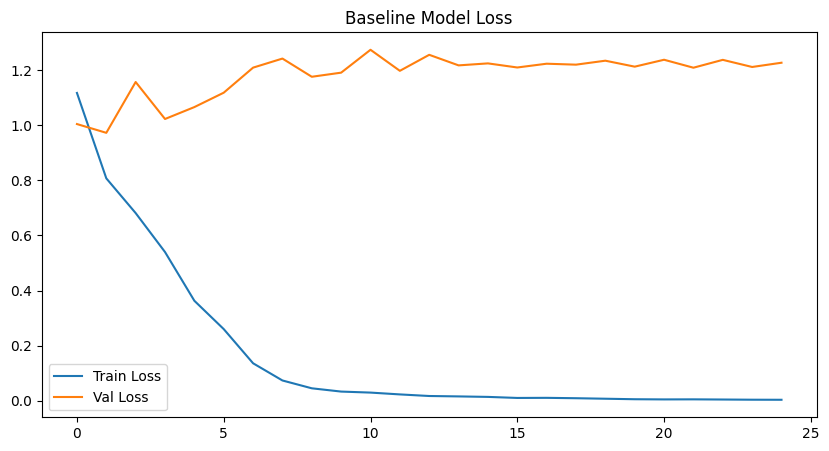

In [ ]:
history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=32,
    verbose=1
)

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(history_baseline.history['loss'], label='Train Loss')
plt.plot(history_baseline.history['val_loss'], label='Val Loss')
plt.title('Baseline Model Loss')
plt.legend()
plt.show()

Hasil training menunjukkan bahwa model mengalami penurunan yang sangat signifikan pada metrik loss dan Mean Absolute Error (MAE) di data training. Pada epoch 1, nilai loss sebesar 1.1182 dan MAE sebesar 0.9033, kemudian terus menurun secara hingga mencapai loss 0.0027 dan MAE 0.0413 pada epoch 25. Hal ini menunjukkan bahwa model sangat baik dalam mempelajari pola pada data training.

Namun, berbeda pada data validasi. Nilai val_loss dan val_MAE tidak menunjukkan penurunan yang konsisten. Val_loss berada di kisaran sekitar 0.97 hingga 1.27 tanpa penurunan yang jelas. Begitu juga dengan val_MAE yang berada di sekitar 0.86 hingga 0.95 dan tidak mengalami perbaikan selama proses training. Hal ini menunjukkan bahwa peningkatan performa pada data training tidak diikuti oleh peningkatan performa pada data validasi.

Dari pola tersebut dapat disimpulkan bahwa model mengalami overfitting, yaitu kondisi ketika model terlalu menyesuaikan diri terhadap data training sehingga kehilangan kemampuan untuk melakukan generalisasi pada data baru.

## No 1 c

In [ ]:
# Modifikasi: Tambah layer, Dropout untuk regulasi, dan Batch Normalization
modified_model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(input_dim,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='linear')
])

In [ ]:
# Menggunakan Learning Rate yang lebih kecil agar konvergensi lebih stabil
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
modified_model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

In [ ]:
# Early Stopping untuk mencegah overfitting
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [ ]:
history_modified = modified_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50, # Lebih banyak epoch tapi ada early stopping
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Alasan Modifikasi:
# 1. BatchNormalization: Menstabilkan proses training.
# 2. Dropout: Mencegah model terlalu 'menghafal' data training (anti-overfitting).
# 3. EarlyStopping: Menghentikan training saat performa validasi berhenti membaik.

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 1.7895 - mae: 1.1032 - val_loss: 0.9722 - val_mae: 0.8478
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.3020 - mae: 0.9299 - val_loss: 0.9652 - val_mae: 0.8457
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0856 - mae: 0.8692 - val_loss: 0.9713 - val_mae: 0.8469
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.8874 - mae: 0.7697 - val_loss: 0.9616 - val_mae: 0.8423
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9013 - mae: 0.7852 - val_loss: 0.9610 - val_mae: 0.8404
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7975 - mae: 0.7287 - val_loss: 0.9601 - val_mae: 0.8377
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7851 - mae: 0.7226 - val_loss: 0.9551 - val_mae: 0.8363
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6441 - mae: 0.6591 - val_loss: 0.9464 - val_mae: 0.8347
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.619

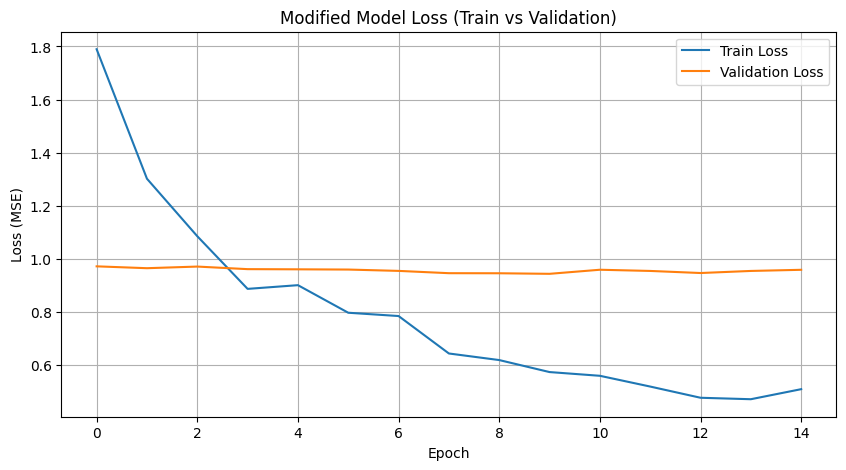

In [ ]:
plt.figure(figsize=(10,5))

train_loss = history_modified.history['loss']
val_loss = history_modified.history['val_loss']

plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')

plt.title('Modified Model Loss (Train vs Validation)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid()

plt.show()

dilakukan beberapa modifikasi yaitu pertama Penambahan layer Dense dengan jumlah neuron yang lebih terstruktur untuk meningkatkan kemampuan model dalam menangkap pola yang lebih kompleks secara bertahap. Namun, agar tidak membuat model menjadi terlalu kompleks, digunakan juga regularisasi berupa Dropout pada beberapa layer. Dropout berfungsi untuk mematikan sebagian neuron secara acak selama training, sehingga model tidak terlalu bergantung pada pola tertentu dan menjadi lebih robust.

Selain itu, Batch Normalization ditambahkan untuk menstabilkan distribusi input pada setiap layer selama proses training. Hal ini membantu mempercepat konvergensi dan lebih stabil. Penggunaan learning rate yang lebih kecil juga dilakukan, sehingga model dapat mencapai titik optimum secara lebih baik.

Terakhir, Early Stopping digunakan untuk mencegah overfitting dengan menghentikan training secara otomatis ketika performa pada data validasi tidak lagi membaik dalam beberapa epoch.

Hasil training pada model yang sudah dimodifikasi menunjukkan perubahan yang dibandingkan model sebelumnya. Pada awal training (epoch 1), nilai loss pada data training masih cukup tinggi yaitu 1.7895 dengan MAE sebesar 1.1032, namun secara bertahap menurun hingga sekitar loss 0.5098 dan MAE 0.5810 pada epoch 15. Penurunan ini menunjukkan bahwa model tetap mampu belajar dari data training, meskipun prosesnya lebih lambat dan lebih stabil akibat penggunaan learning rate yang lebih kecil serta regularisasi seperti dropout dan batch normalization.

Pada data validasi, performa model terlihat jauh lebih stabil dibandingkan sebelumnya. Nilai val_loss berada pada rentang sekitar 0.94 hingga 0.97, sementara val_MAE berada di kisaran 0.83 hingga 0.84. tidak terlihat lonjakan besar seperti pada model sebelumnya, sehingga dapat dikatakan bahwa model yang dimodifikasi lebih mampu menjaga kestabilan performa pada data yang belum pernah dilihat.

Selain itu, tidak terlihat tanda overfitting yang parah seperti sebelumnya, karena jarak antara performa training dan validation tidak terlalu ekstrem. Meskipun training loss masih lebih rendah dibandingkan validation loss, selisihnya jauh lebih wajar dan tidak menunjukkan model yang menghafal data training secara berlebihan. Hal ini menunjukkan bahwa kombinasi Batch Normalization, Dropout, learning rate yang lebih kecil, dan Early Stopping berhasil meningkatkan kemampuan generalisasi model.

## No 1 d

In [ ]:
def evaluate_model(model, X, y_true, scaler, name):
    preds = model.predict(X)
    # Inverse transform untuk mengembalikan ke satuan hg/ha
    y_true_inv = scaler.inverse_transform(y_true)
    preds_inv = scaler.inverse_transform(preds)

    mae = mean_absolute_error(y_true_inv, preds_inv)
    rmse = np.sqrt(mean_squared_error(y_true_inv, preds_inv))
    r2 = r2_score(y_true_inv, preds_inv)

    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results_baseline = evaluate_model(baseline_model, X_test, y_test, scaler_y, "Baseline")
results_modified = evaluate_model(modified_model, X_test, y_test, scaler_y, "Modified")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


In [ ]:
# Perbandingan Tabel
comparison_df = pd.DataFrame([results_baseline, results_modified])
print("\n--- Perbandingan Evaluasi (Data Test) ---")
print(comparison_df)

# Analisis & Kesimpulan
# Jika R2 mendekati 1, model sangat baik.
# Jika MAE Modified < MAE Baseline, maka modifikasi berhasil meningkatkan akurasi.


--- Perbandingan Evaluasi (Data Test) ---
      Model           MAE          RMSE        R2
0  Baseline  10762.996949  12613.819598 -0.152074
1  Modified  10513.329711  11702.725242  0.008344


Berdasarkan hasil evaluasi pada data test, terlihat adanya perbaikan performa setelah model dimodifikasi. Pada model baseline, nilai MAE sebesar 10.762,99 dan RMSE sebesar 12.613,82 dengan nilai R square sebesar -0.152. Nilai R square yang negatif menunjukkan bahwa model baseline sangat buruk, sehingga generalisasi model awal masih sangat lemah.

Setelah dilakukan modifikasi, terjadi peningkatan performa pada seluruh metrik evaluasi. Nilai MAE menurun menjadi 10.513,33 dan RMSE juga berkurang menjadi 11.702,73. Penurunan MAE dan RMSE ini menunjukkan bahwa rata-rata kesalahan prediksi model menjadi lebih kecil, sehingga hasil prediksi lebih mendekati nilai aktual dibandingkan model sebelumnya. Selain itu, nilai R square meningkat menjadi 0.008, yang meskipun masih sangat kecil, menunjukkan adanya perbaikan dalam menjelaskan variasi data dibandingkan model baseline yang bernilai negatif.